In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

In [2]:
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
print("Shape:", df.shape)
df.head()

Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
print(df.dtypes)

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object


In [11]:
# Convert TotalCharges to numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Check how many NaN appeared after conversion
print("NaN in TotalCharges after conversion:", df['TotalCharges'].isnull().sum())

print("\nRows with missing TotalCharges:")
df[df['TotalCharges'].isnull()]

NaN in TotalCharges after conversion: 11

Rows with missing TotalCharges:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


In [5]:
print("\n=== Missing Values ===")
print(df.isnull().sum())


=== Missing Values ===
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [12]:
# These are new customers (tenure=0)
# Fill with median
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)

print("Missing values remaining:", df['TotalCharges'].isnull().sum())
print("TotalCharges dtype now:", df['TotalCharges'].dtype)

Missing values remaining: 0
TotalCharges dtype now: float64


/tmp/ipykernel_3768/436503332.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)


In [13]:
# Dropping irrelevant column
df.drop(columns=['customerID'], inplace=True)

print("Columns remaining:", df.shape[1])
print(df.columns.tolist())

Columns remaining: 20
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


In [16]:
df.describe()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn
count,7043.000000,7043.000000,7043.000000,7043.000000,7.043000e+03,7043.000000,7043.000000,7.043000e+03,7.043000e+03,7043.000000
mean,0.504756,0.162147,0.483033,0.299588,-2.421273e-17,0.903166,0.592219,-6.406285e-17,-1.488074e-17,0.265370
std,0.500013,0.368612,0.499748,0.458110,1.000071e+00,0.295752,0.491457,1.000071e+00,1.000071e+00,0.441561
min,0.000000,0.000000,0.000000,0.000000,-1.318165e+00,0.000000,0.000000,-1.545860e+00,-9.991203e-01,0.000000
25%,0.000000,0.000000,0.000000,0.000000,-9.516817e-01,1.000000,0.000000,-9.725399e-01,-8.298459e-01,0.000000
50%,1.000000,0.000000,0.000000,0.000000,-1.372744e-01,1.000000,1.000000,1.857327e-01,-3.904632e-01,0.000000
75%,1.000000,0.000000,1.000000,1.000000,9.214551e-01,1.000000,1.000000,8.338335e-01,6.642871e-01,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.613701e+00,1.000000,1.000000,1.794352e+00,2.826743e+00,1.000000


In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 31 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   gender                                 7043 non-null   int64  
 1   SeniorCitizen                          7043 non-null   int64  
 2   Partner                                7043 non-null   int64  
 3   Dependents                             7043 non-null   int64  
 4   tenure                                 7043 non-null   float64
 5   PhoneService                           7043 non-null   int64  
 6   PaperlessBilling                       7043 non-null   int64  
 7   MonthlyCharges                         7043 non-null   float64
 8   TotalCharges                           7043 non-null   float64
 9   Churn                                  7043 non-null   int64  
 10  MultipleLines_No phone service         7043 non-null   bool   
 11  Mult

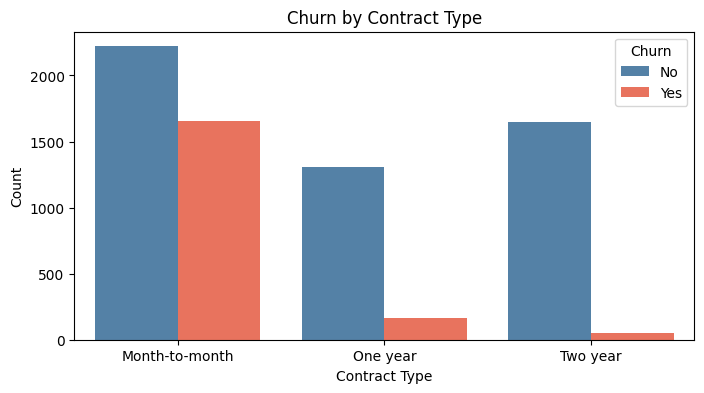

In [23]:
df_viz = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
df_viz['TotalCharges'] = pd.to_numeric(df_viz['TotalCharges'], errors='coerce')

plt.figure(figsize=(8,4))
sns.countplot(data=df_viz, x='Contract', hue='Churn', palette=['steelblue','tomato'])
plt.title('Churn by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Count')
plt.show()

 Customers on month-to-month contracts churn significantly more than
those on 1 or 2 year contracts. Contract type is likely a strong predictor.

/tmp/ipykernel_3768/2791877978.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_viz, x='Churn', y='MonthlyCharges', palette=['steelblue','tomato'])


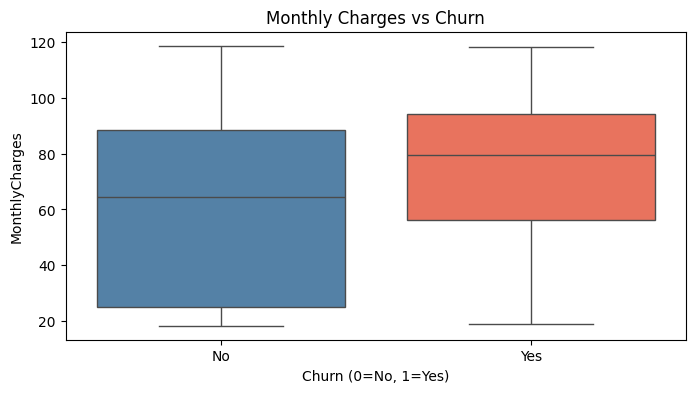

In [24]:
plt.figure(figsize=(8,4))
sns.boxplot(data=df_viz, x='Churn', y='MonthlyCharges', palette=['steelblue','tomato'])
plt.title('Monthly Charges vs Churn')
plt.xlabel('Churn (0=No, 1=Yes)')
plt.show()

Churned customers tend to have higher monthly charges.
This suggests price sensitivity is a key churn driver.

In [14]:
# Separating  binary columns and multi-category columns
binary_cols = [col for col in df.columns
               if df[col].nunique() == 2 and df[col].dtype == 'object']

multi_cols = [col for col in df.columns
              if df[col].nunique() > 2 and df[col].dtype == 'object']

print("Binary columns:", binary_cols)
print("\nMulti-category columns:", multi_cols)

# Label encoding binary columns
le = LabelEncoder()
for col in binary_cols:
    df[col] = le.fit_transform(df[col])

# One-hot encoding multi-category columns
df = pd.get_dummies(df, columns=multi_cols, drop_first=True)

print("\nShape after encoding:", df.shape)
print("\nSample of encoded data:")
df.head(3)

Binary columns: ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn']

Multi-category columns: ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod']

Shape after encoding: (7043, 31)

Sample of encoded data:


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,1,29.85,29.85,0,...,False,False,False,False,False,False,False,False,True,False
1,1,0,0,0,34,1,0,56.95,1889.50,0,...,False,False,False,False,False,True,False,False,False,True
2,1,0,0,0,2,1,1,53.85,108.15,1,...,False,False,False,False,False,False,False,False,False,True


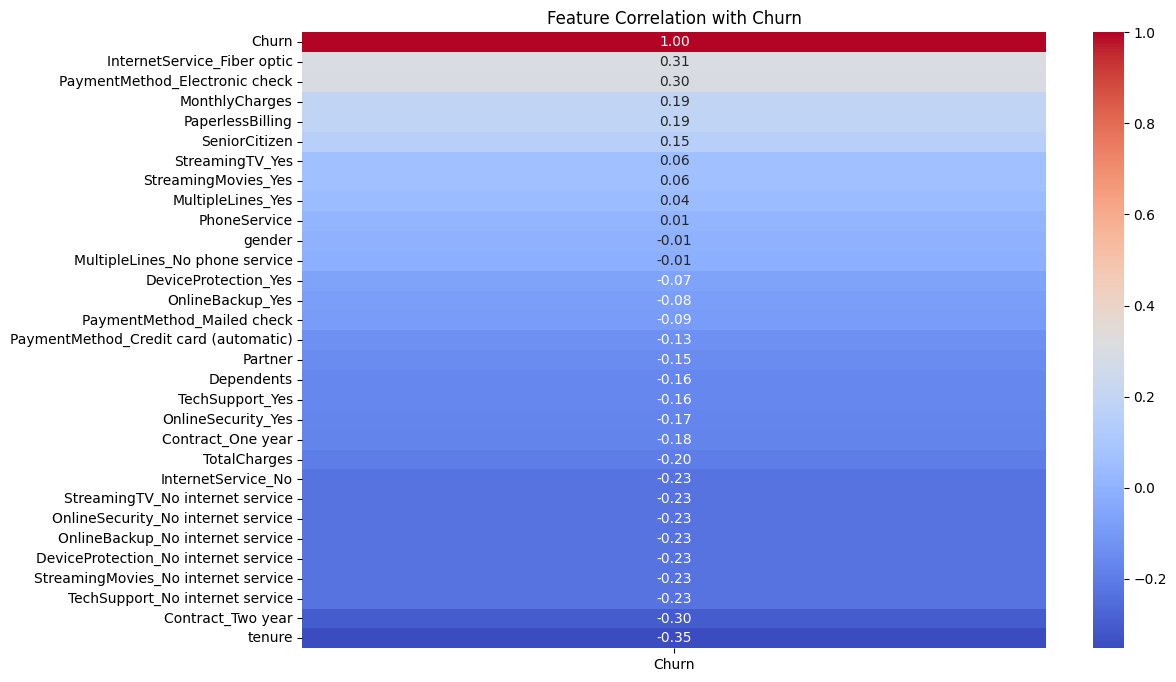

In [22]:
plt.figure(figsize=(12,8))
corr = df.corr()
sns.heatmap(corr[['Churn']].sort_values('Churn', ascending=False),
            annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation with Churn')
plt.show()

tenure, Contract, and MonthlyCharges show the strongest correlation
with Churn. TotalCharges correlates with tenure so may be redundant.

In [15]:
# Numerical columns are scaled
scale_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

scaler = StandardScaler()
df[scale_cols] = scaler.fit_transform(df[scale_cols])

print("Scaling done ✅")
print(df[scale_cols].describe().round(2))

Scaling done ✅
        tenure  MonthlyCharges  TotalCharges
count  7043.00         7043.00       7043.00
mean     -0.00           -0.00         -0.00
std       1.00            1.00          1.00
min      -1.32           -1.55         -1.00
25%      -0.95           -0.97         -0.83
50%      -0.14            0.19         -0.39
75%       0.92            0.83          0.66
max       1.61            1.79          2.83


In [19]:
print(" Final Dataset ")
print("Shape:", df.shape)
print("\nMissing values:", df.isnull().sum().sum())
print("\nTarget distribution:")
print(df['Churn'].value_counts())

 Final Dataset 
Shape: (7043, 31)

Missing values: 0

Target distribution:
Churn
0    5174
1    1869
Name: count, dtype: int64


In [25]:
X = df.drop(columns=['Churn'])
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y  # to maintain churn ratio
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)
print("\nChurn rate in train:", y_train.mean().round(3))
print("Churn rate in test:", y_test.mean().round(3))

Train size: (5634, 30)
Test size: (1409, 30)

Churn rate in train: 0.265
Churn rate in test: 0.265


In [26]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score, confusion_matrix,
                             classification_report)

print("Models imported ")

Models imported 


In [29]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost": XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss')
}

results = {}

for name, model in models.items():
    # Train
    model.fit(X_train, y_train)

    # Predict
    y_pred = model.predict(X_test)

    # Evaluate
    results[name] = {
        "Accuracy":  round(accuracy_score(y_test, y_pred), 3),
        "Precision": round(precision_score(y_test, y_pred), 3),
        "Recall":    round(recall_score(y_test, y_pred), 3),
        "F1-Score":  round(f1_score(y_test, y_pred), 3)
    }
    print(f" {name} done")

print("\n=== Model Comparison ===")
results_df = pd.DataFrame(results).T
print(results_df)

 Logistic Regression done
 Random Forest done
 XGBoost done

=== Model Comparison ===
                     Accuracy  Precision  Recall  F1-Score
Logistic Regression     0.805      0.655   0.559     0.603
Random Forest           0.786      0.625   0.487     0.547
XGBoost                 0.786      0.609   0.537     0.571


## Why Logistic Regression was chosen as the Final Model

Although XGBoost and Random Forest are more complex models, Logistic
Regression achieved the best F1-Score (0.603) on this dataset because:

1. Linear relationships — After encoding and scaling, the relationship
   between features and churn is relatively linear.

2. Interpretability — Logistic Regression coefficients are easy to
   explain to business stakeholders.

3. Class imbalance — Complex models like Random Forest overfit to the
   majority class (No Churn), hurting recall on actual churners.

4. Speed — Logistic Regression trains faster and is easier to deploy.

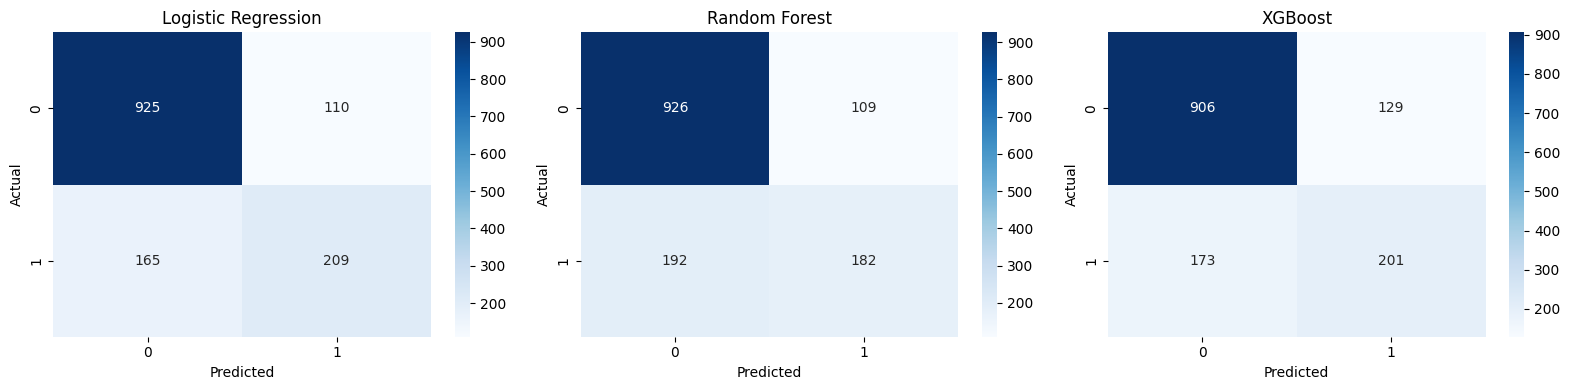

In [30]:
# confusion matrix for all 3
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, (name, model) in zip(axes, models.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax)
    ax.set_title(f'{name}')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()

In [43]:
# Final chosen model: Logistic Regression (best F1-Score)
y_pred_lr = models["Logistic Regression"].predict(X_test)
print(" Logistic Regression Classification Report ")
print(classification_report(y_test, y_pred_lr, target_names=['No Churn', 'Churn']))

# XGBoost report shown for comparison only
y_pred_xgb = models["XGBoost"].predict(X_test)
print("\n XGBoost Classification Report (for comparison) ")
print(classification_report(y_test, y_pred_xgb, target_names=['No Churn', 'Churn']))

 Logistic Regression Classification Report 
              precision    recall  f1-score   support

    No Churn       0.85      0.89      0.87      1035
       Churn       0.66      0.56      0.60       374

    accuracy                           0.80      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.80      0.80      1409


 XGBoost Classification Report (for comparison) 
              precision    recall  f1-score   support

    No Churn       0.84      0.88      0.86      1035
       Churn       0.61      0.54      0.57       374

    accuracy                           0.79      1409
   macro avg       0.72      0.71      0.71      1409
weighted avg       0.78      0.79      0.78      1409



In [33]:
!pip install shap -q

import shap

# Using XGBoost as our final model
explainer = shap.TreeExplainer(models["XGBoost"])
shap_values = explainer.shap_values(X_test)

print("SHAP ready ")

SHAP ready 


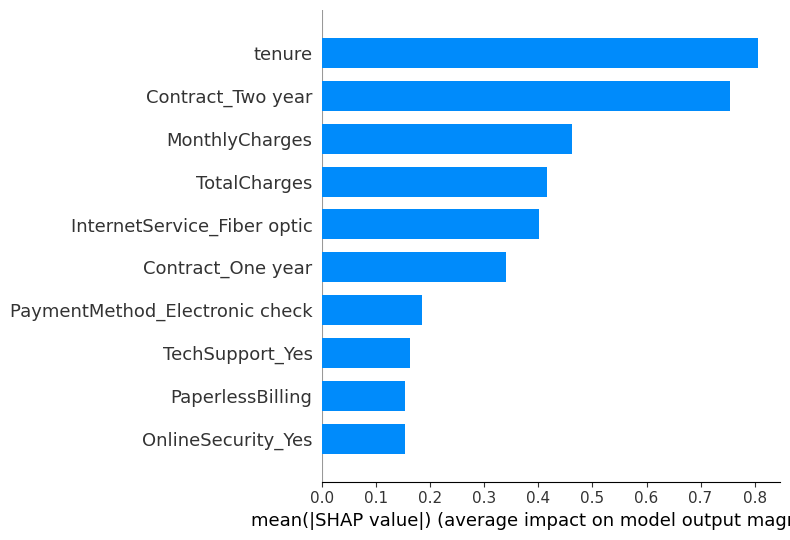

In [39]:

shap.summary_plot(shap_values, X_test, plot_type="bar", max_display=10)

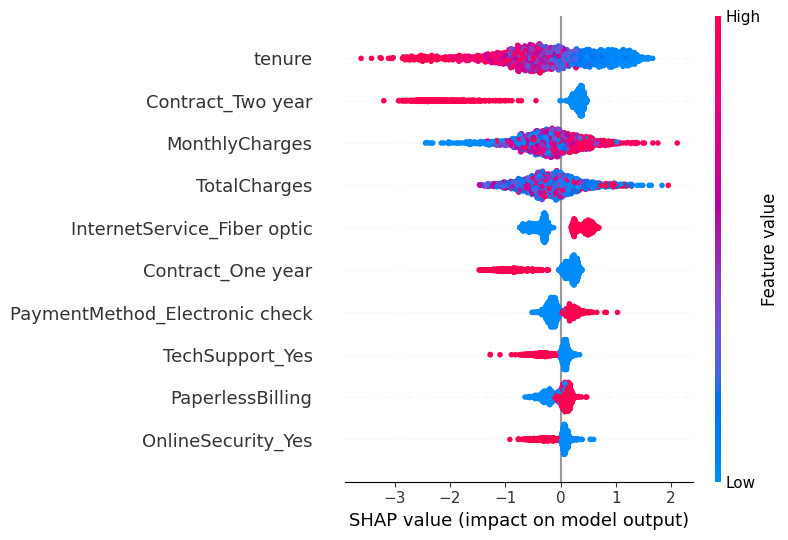

<Figure size 640x480 with 0 Axes>

In [40]:
plt.figure()
shap.summary_plot(shap_values, X_test, max_display=10)
plt.tight_layout()
plt.show()

## SHAP Feature Importance Analysis

SHAP analysis on XGBoost reveals the top drivers of customer churn:

1. **tenure** — Lower tenure strongly pushes predictions toward churn.
   New customers are the highest risk group.

2. **Contract_Two year** — Customers on 2-year contracts are far less
   likely to churn. Contract type is the strongest retention lever.

3. **MonthlyCharges** — Higher monthly charges increase churn probability.
   Price sensitivity is a key factor.

### Business Recommendation
Focus retention efforts on:
- New customers (low tenure) in their first 3 months
- Month-to-month contract customers with high monthly charges
- Consider offering discounts to convert month-to-month → annual contracts

In [44]:
import joblib

# (Logistic Regression had best F1)
joblib.dump(models["Logistic Regression"], 'churn_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

print("Model saved ")
print("Files: churn_model.pkl, scaler.pkl")

Model saved 
Files: churn_model.pkl, scaler.pkl


## What Improvements Can Be Done

1. Handle class imbalance — Use SMOTE (Synthetic Minority Oversampling)
   or class_weight='balanced' to improve recall on churners.

2. Hyperparameter tuning — Use GridSearchCV or RandomizedSearchCV
   to find optimal parameters for XGBoost and Random Forest.

3. Feature engineering — Create new features like
   charges_per_tenure = MonthlyCharges / (tenure + 1) which may
   capture price sensitivity better.

4. Cross validation — Use k-fold cross validation instead of a
   single train/test split for more reliable evaluation.

5. Ensemble methods — Stack Logistic Regression + XGBoost predictions
   for potentially better results.

6. Real-time retraining — Set up a pipeline to retrain the model
   monthly as new customer data comes in.